In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
file_path = 'C:/Users/thomd/My Drive (thomderuwe@gmail.com)/Thesis/Dataset/Pre-processing set.csv'
df = pd.read_csv(file_path)  

In [5]:
file_path = pre_processing_set
df = pd.read_csv(file_path)
df = df.drop(df.columns[:5], axis=1)
df.to_csv(pre_processing_set, index = False)

In [6]:
# one-hot encoder setup
encoder = OneHotEncoder(sparse_output = False, 
                        handle_unknown = 'ignore')

In [7]:
# One-hot encoding home_ownership_n
df['home_ownership_n'] = df['home_ownership_n'].astype('category')
home_ownership_encoded_array = encoder.fit_transform(df[['home_ownership_n']])
home_ownership_columns = encoder.get_feature_names_out(['home_ownership_n'])

home_ownership_encoded = pd.DataFrame(home_ownership_encoded_array, 
                                   columns = home_ownership_columns,
                                   index = df.index)
df = pd.concat([df, home_ownership_encoded], axis = 1)
df.to_csv(pre_processing_set, index=False) 

In [8]:
# one-hot encoding purpose
df['purpose'] = df['purpose'].astype('category')
purpose_encoded_array = encoder.fit_transform(df[['purpose']])
purpose_columns = encoder.get_feature_names_out(['purpose'])

purpose_encoded = pd.DataFrame(purpose_encoded_array, 
                                   columns = purpose_columns,
                                   index = df.index)
df = pd.concat([df, purpose_encoded], axis = 1)
df.to_csv(pre_processing_set, index=False) 

In [9]:
# Ordinal encoding emp_order
emp_order = ['< 1 year',
             '1 year',
             '2 years',
             '3 years',
             '4 years',
             '5 years',
             '6 years',
             '7 years',
             '8 years',
             '9 years',
             '10+ years',
             'NI']
ordinal_encoder =  OrdinalEncoder(categories = [emp_order])
df['encoded_emp_length'] = ordinal_encoder.fit_transform(df[['emp_length']])
df.to_csv(file_path, index=False)

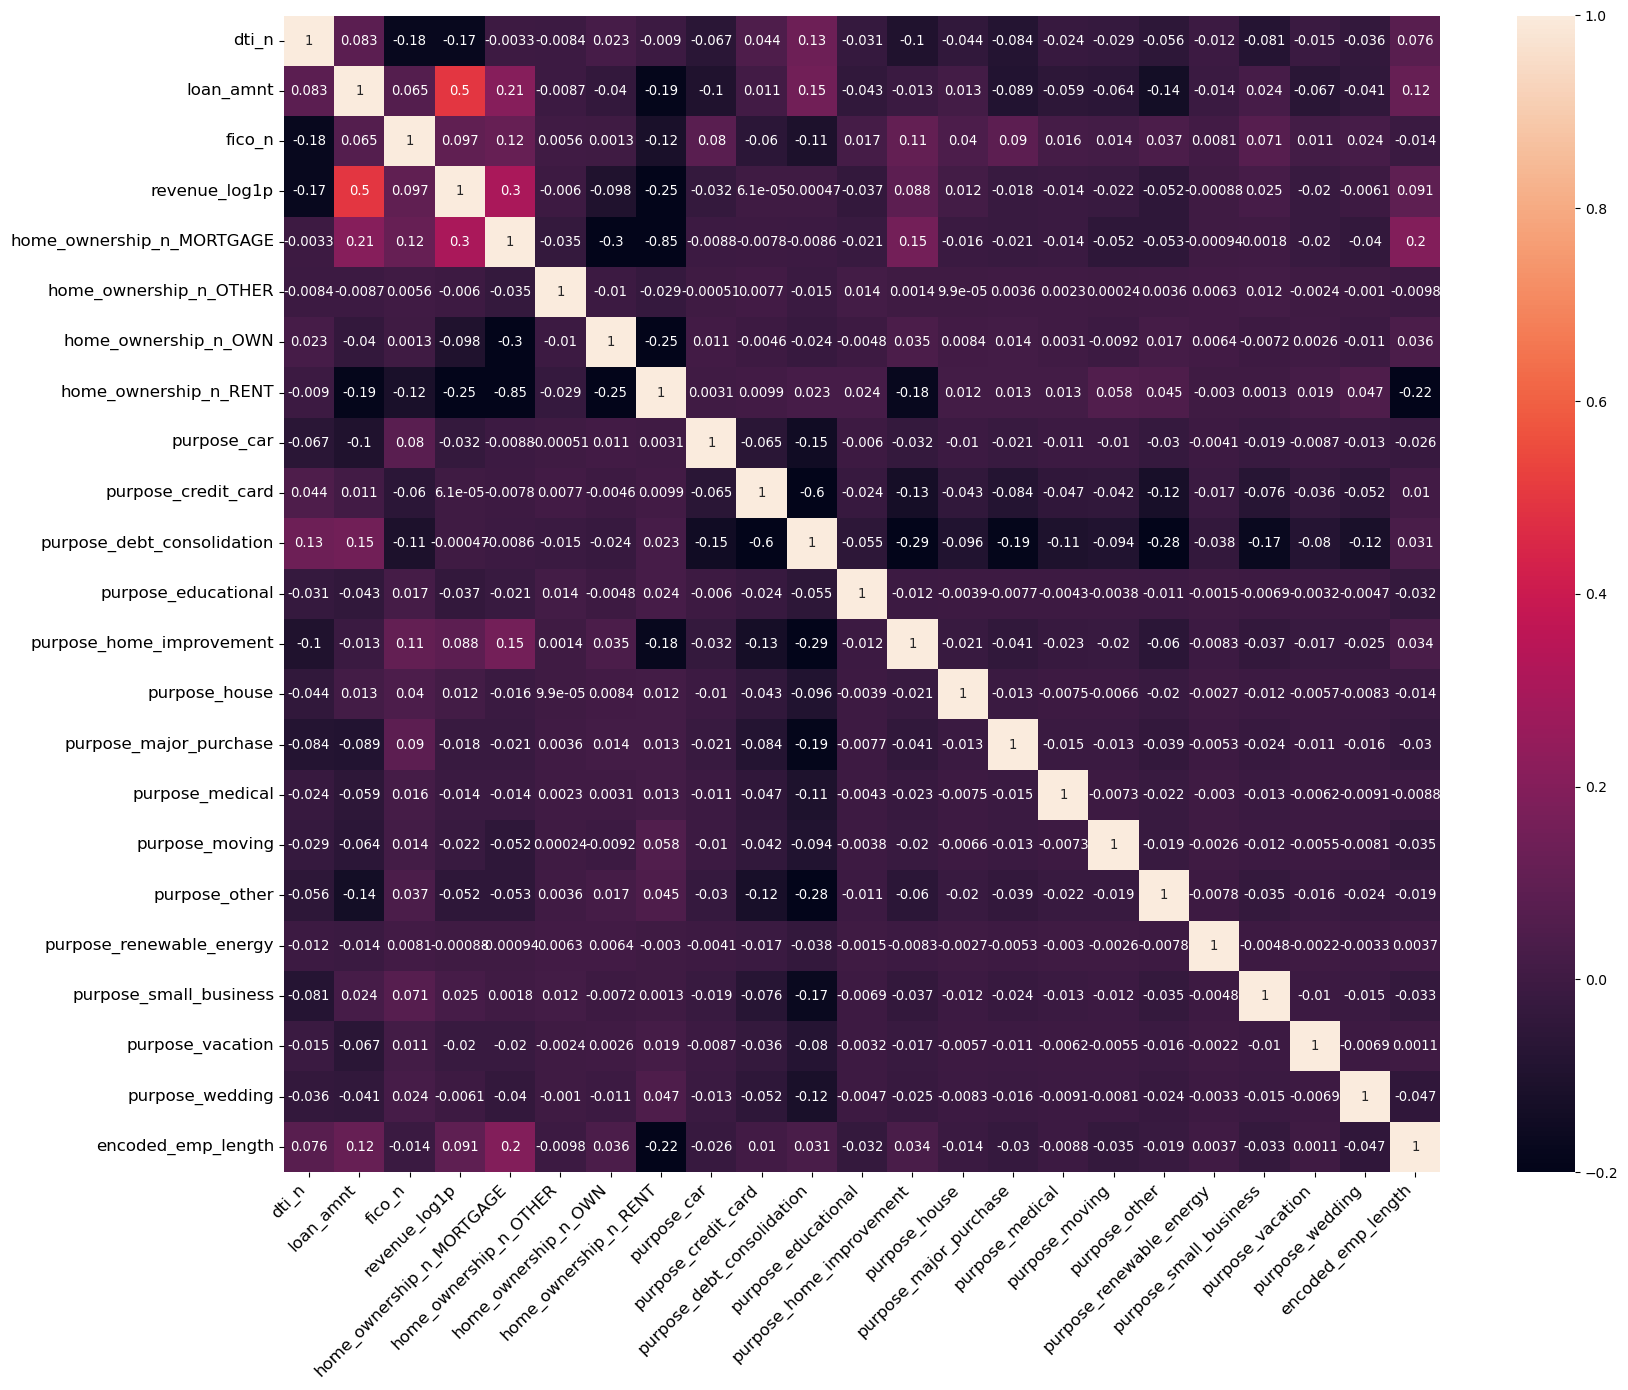

In [29]:
# Total correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

nummeric = df.select_dtypes(include = 'number')
cols_to_remove = ['experience_c', 'revenue', 'Default'] 
relevant = nummeric.drop(columns = cols_to_remove).corr()


plt.figure(figsize=(18, 14))

sns.heatmap(
    relevant,
    annot=True,
    fmt=".2g",
    cmap="rocket",
    square=True,
    cbar=True,
    linewidths=0,
    vmin=-0.2,
    vmax=1,
    annot_kws={"size": 9.5}
)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()